In [1]:
%matplotlib inline

# scientific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version is: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

The current HDDM version is:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


In [2]:
# read data
data = pd.read_csv('MS_categ_val_hddm_stim.csv')
data

,subj_idx,val,id,stim,response,rt
0,7304,Bad,Self,0,0,0.6812
1,7304,Good,Other,1,1,0.8496
2,7304,Good,Self,1,1,0.9578
3,7304,Bad,Other,0,0,0.5619
4,7304,Good,Self,1,1,0.6939
...,...,...,...,...,...,...
14426,7345,Good,Self,1,1,0.4139
14427,7345,Good,Other,1,1,0.5393
14428,7345,Bad,Self,0,0,0.4664
14429,7345,Good,Other,1,1,0.4763


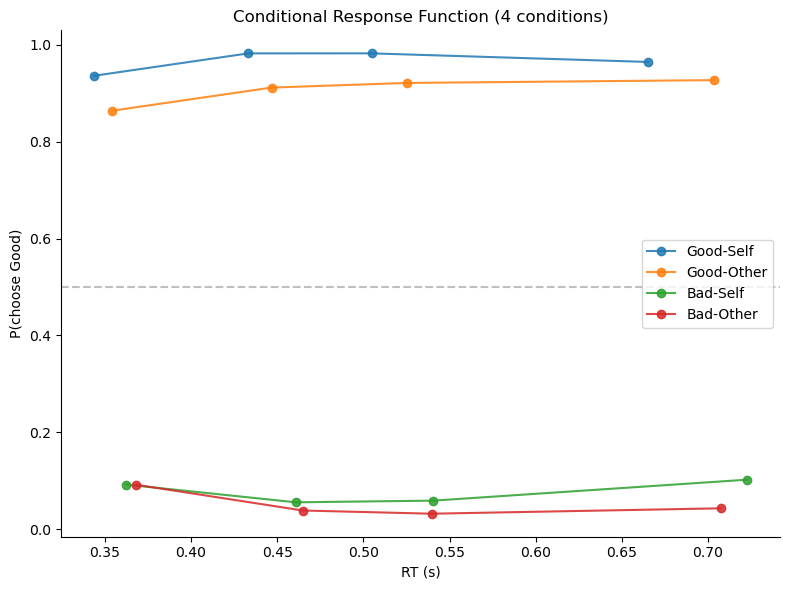

In [4]:
def conditional_response_plot(df, target=1):
    # 条件反应函数：四个条件（Good/Bad x Self/Other）选择 Self 的概率随 RT 变化
    quantiles = [0, 0.25, 0.5, 0.75, 1]
    df = df.copy()
    df['condition'] = df['val'] + '-' + df['id']

    cond_order = ['Good-Self', 'Good-Other', 'Bad-Self', 'Bad-Other']
    cond_colors = {'Good-Self': '#1f77b4', 'Good-Other': '#ff7f0e',
                     'Bad-Self': '#2ca02c', 'Bad-Other': '#d62728'}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cond in cond_order:
        c = df[df['condition'] == cond].copy()
        c['rt_bin'] = pd.qcut(c['rt'], quantiles, labels=False, duplicates='drop')
        g = c.groupby('rt_bin').agg(rt=('rt', 'mean'),
                                    prob=('response', lambda x: (x == target).mean())).reset_index()
        ax.plot(g['rt'], g['prob'], '-o', color=cond_colors[cond], label=cond, alpha=0.85)

    ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
    ax.set(xlabel='RT (s)',
             ylabel='P(choose Good)' if target == 1 else 'P(choose Bad)')
    ax.set_title('Conditional Response Function (4 conditions)')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    return fig

fig = conditional_response_plot(data, target=1)
plt.show()

In [5]:
# accuracy coding
data['choice'] = data['response'].copy()                       # 保存 choice 编码（1=Self, 0=Other）
data['acc'] = (data['response'] == data['stim']).astype(int)   # 计算正确率

data['response'] = data['acc']  

In [6]:
#hddm_acc coding
hddm_val_m0_acc = hddm.HDDM(data, include=['a', 'v', 't','z'], depends_on={'z': 'val'})

hddm_val_m0_acc_idata = hddm_val_m0_acc.sample(5000, burn=1000, return_infdata=True, chains=4, dbname = 'hddm_val_m0_acc.db', db = 'pickle')
hddm_val_m0_acc.save('hddm_val_m0_acc.hddm')
# hddm.load('hddm_val_m0_acc.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[                  0%                  ] 7 of 5000 complete in 0.6 sec
[                  0%                  ] 14 of 5000 complete in 1.1 sec
[                  0%                  ] 21 of 5000 complete in 1.6 sec
[                  0%                  ] 28 of 5000 complete in 2.1 sec
[                  0%                  ] 35 of 5000 complete in 2.7 sec
[                  0%                  ] 42 of 5000 complete in 3.2 sec
[                  0%                  ] 49 of 5000 complete in 3.7 sec
[                  1%                  ] 56 of 5000 complete in 4.3 sec
[                  1%                  ] 63 of 5000 complete in 4.8 sec
[                  1%                  ] 70 of 5000 complete in 5.3 sec
[                  1%                  ] 77 of 5000 complete in 5.9 sec
[                  1%                  ] 84 of 5000 complete in 6.4 sec
[                  1%                  ] 91 of 5000 complete in 6.9 sec
[                  1%                  ] 98 of 5000 complete in 7

[                  0%                  ] 7 of 5000 complete in 0.6 sec
[                  0%                  ] 14 of 5000 complete in 1.1 sec
[                  0%                  ] 21 of 5000 complete in 1.7 sec
[                  0%                  ] 28 of 5000 complete in 2.2 sec
[                  0%                  ] 35 of 5000 complete in 2.7 sec
[                  0%                  ] 42 of 5000 complete in 3.3 sec
[                  0%                  ] 49 of 5000 complete in 3.8 sec
[                  1%                  ] 56 of 5000 complete in 4.3 sec
[                  1%                  ] 63 of 5000 complete in 4.9 sec
[                  1%                  ] 70 of 5000 complete in 5.4 sec
[                  1%                  ] 77 of 5000 complete in 6.0 sec
[                  1%                  ] 84 of 5000 complete in 6.5 sec
[                  1%                  ] 91 of 5000 complete in 7.1 sec
[                  1%                  ] 98 of 5000 complete in 7

[-----            15%                  ] 784 of 5000 complete in 60.2 sec
[------           15%                  ] 791 of 5000 complete in 60.7 sec
[------           15%                  ] 798 of 5000 complete in 61.2 sec
[------           16%                  ] 805 of 5000 complete in 61.8 sec
[------           16%                  ] 812 of 5000 complete in 62.3 sec
[------           16%                  ] 819 of 5000 complete in 62.9 sec
[------           16%                  ] 826 of 5000 complete in 63.4 sec
[------           16%                  ] 833 of 5000 complete in 63.9 sec
[------           16%                  ] 840 of 5000 complete in 64.4 sec
[------           16%                  ] 847 of 5000 complete in 65.0 sec
[------           17%                  ] 854 of 5000 complete in 65.5 sec
[------           17%                  ] 861 of 5000 complete in 66.1 sec
[------           17%                  ] 868 of 5000 complete in 66.6 sec
[------           17%                 

...

[-----------------45%                  ] 2296 of 5000 complete in 177.1 sec
[-----------------46%                  ] 2303 of 5000 complete in 177.6 sec
[-----------------46%                  ] 2310 of 5000 complete in 178.2 sec
[-----------------46%                  ] 2317 of 5000 complete in 178.7 sec
[-----------------46%                  ] 2324 of 5000 complete in 179.3 sec
[-----------------46%                  ] 2331 of 5000 complete in 179.8 sec
[-----------------46%                  ] 2338 of 5000 complete in 180.3 sec
[-----------------46%                  ] 2345 of 5000 complete in 180.8 sec
[-----------------47%                  ] 2352 of 5000 complete in 181.4 sec
[-----------------47%                  ] 2359 of 5000 complete in 181.9 sec
[-----------------47%                  ] 2366 of 5000 complete in 182.4 sec
[-----------------47%                  ] 2373 of 5000 complete in 183.0 sec
[-----------------47%                  ] 2380 of 5000 complete in 183.5 sec
[-----------

[-----------------60%---               ] 3045 of 5000 complete in 233.6 sec
[-----------------61%---               ] 3052 of 5000 complete in 234.2 sec
[-----------------61%---               ] 3059 of 5000 complete in 234.7 sec
[-----------------61%---               ] 3066 of 5000 complete in 235.2 sec
[-----------------61%---               ] 3073 of 5000 complete in 235.8 sec
[-----------------61%---               ] 3080 of 5000 complete in 236.4 sec
[-----------------61%---               ] 3087 of 5000 complete in 236.9 sec
[-----------------61%---               ] 3094 of 5000 complete in 237.5 sec
[-----------------62%---               ] 3101 of 5000 complete in 238.0 sec
[-----------------62%---               ] 3108 of 5000 complete in 238.6 sec
[-----------------62%---               ] 3115 of 5000 complete in 239.1 sec
[-----------------62%---               ] 3122 of 5000 complete in 239.7 sec
[-----------------62%---               ] 3129 of 5000 complete in 240.2 sec
[-----------

[-----------------60%---               ] 3045 of 5000 complete in 234.4 sec
[-----------------61%---               ] 3052 of 5000 complete in 234.9 sec
[-----------------61%---               ] 3059 of 5000 complete in 235.5 sec
[-----------------61%---               ] 3065 of 5000 complete in 236.0 sec
[-----------------61%---               ] 3072 of 5000 complete in 236.6 sec
[-----------------61%---               ] 3079 of 5000 complete in 237.1 sec
[-----------------61%---               ] 3086 of 5000 complete in 237.7 sec
[-----------------61%---               ] 3093 of 5000 complete in 238.2 sec
[-----------------62%---               ] 3100 of 5000 complete in 238.8 sec
[-----------------62%---               ] 3107 of 5000 complete in 239.3 sec
[-----------------62%---               ] 3114 of 5000 complete in 239.8 sec
[-----------------62%---               ] 3121 of 5000 complete in 240.4 sec
[-----------------62%---               ] 3128 of 5000 complete in 240.9 sec
[-----------

[-----------------75%--------          ] 3794 of 5000 complete in 291.4 sec
[-----------------76%--------          ] 3801 of 5000 complete in 291.9 sec
[-----------------76%--------          ] 3808 of 5000 complete in 292.4 sec
[-----------------76%--------          ] 3815 of 5000 complete in 293.0 sec
[-----------------76%---------         ] 3822 of 5000 complete in 293.5 sec
[-----------------76%---------         ] 3829 of 5000 complete in 294.0 sec
[-----------------76%---------         ] 3836 of 5000 complete in 294.6 sec
[-----------------76%---------         ] 3843 of 5000 complete in 295.1 sec
[-----------------77%---------         ] 3850 of 5000 complete in 295.6 sec
[-----------------77%---------         ] 3857 of 5000 complete in 296.2 sec
[-----------------77%---------         ] 3864 of 5000 complete in 296.7 sec
[-----------------77%---------         ] 3871 of 5000 complete in 297.3 sec
[-----------------77%---------         ] 3878 of 5000 complete in 297.8 sec
[-----------

[-----------------75%--------          ] 3793 of 5000 complete in 292.1 sec
[-----------------76%--------          ] 3800 of 5000 complete in 292.6 sec
[-----------------76%--------          ] 3807 of 5000 complete in 293.1 sec
[-----------------76%--------          ] 3814 of 5000 complete in 293.7 sec
[-----------------76%---------         ] 3821 of 5000 complete in 294.2 sec
[-----------------76%---------         ] 3828 of 5000 complete in 294.7 sec
[-----------------76%---------         ] 3835 of 5000 complete in 295.3 sec
[-----------------76%---------         ] 3842 of 5000 complete in 295.8 sec
[-----------------76%---------         ] 3849 of 5000 complete in 296.4 sec
[-----------------77%---------         ] 3856 of 5000 complete in 296.9 sec
[-----------------77%---------         ] 3863 of 5000 complete in 297.4 sec
[-----------------77%---------         ] 3870 of 5000 complete in 298.0 sec
[-----------------77%---------         ] 3877 of 5000 complete in 298.5 sec
[-----------

In [7]:
# model evaluate
az.summary(hddm_val_m0_acc_idata) 

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.499,0.045,1.415,1.586,0.001,0.001,3426.0,6196.0,1.0
a_std,0.265,0.037,0.202,0.336,0.001,0.001,1730.0,4688.0,1.0
a_subj.7304,1.550,0.075,1.417,1.696,0.002,0.001,1969.0,2785.0,1.0
a_subj.7305,1.774,0.084,1.620,1.932,0.002,0.001,2058.0,3945.0,1.0
a_subj.7306,1.469,0.075,1.334,1.614,0.002,0.001,1636.0,2984.0,1.0
...,...,...,...,...,...,...,...,...,...
z_subj(Good).7344,0.403,0.024,0.356,0.447,0.000,0.000,5896.0,7782.0,1.0
z_subj(Bad).7345,0.297,0.022,0.256,0.336,0.000,0.000,3644.0,6301.0,1.0
z_subj(Good).7345,0.415,0.025,0.367,0.461,0.000,0.000,4936.0,8043.0,1.0
z_subj(Bad).73370,0.315,0.029,0.260,0.371,0.001,0.000,2409.0,4125.0,1.0


In [9]:
hddm_val_m0_acc_stats = hddm_val_m0_acc.gen_stats()
# hddm_val_acc_m0_stats
hddm_val_m0_acc_stats[hddm_val_m0_acc_stats.index.isin(['a', 'v',  'z(Good)', 'z(Bad)'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.498502,0.045396,1.413867,1.467832,1.496998,1.527123,1.593558,0.000755
v,3.404907,0.130101,3.151353,3.317842,3.40305,3.491296,3.66612,0.001574
z(Bad),0.33505,0.008773,0.31809,0.329077,0.335141,0.340767,0.352655,0.000271
z(Good),0.381692,0.009211,0.363353,0.375457,0.381611,0.387979,0.399473,0.000279


In [11]:
# HDDM choice coding 
# z change with different val
data['response'] = data['choice']#修改
hddm_val_m1_choice = hddm.HDDM(data, include=['a', 'v', 't', 'z'], depends_on={'z': 'val'})

hddm_val_m1_choice_idata = hddm_val_m1_choice.sample(5000, burn=1000, chains=4,
                                     return_infdata=True,
                                     dbname='hddm_val_m1_choice.db', db='pickle')
hddm_val_m1_choice.save('hddm_val_m1_choice.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------90%--------------    ] 4541 of 5000 complete in 348.8 sec
[-----------------90%--------------    ] 4548 of 5000 complete in 349.3 sec
[-----------------91%--------------    ] 4555 of 5000 complete in 349.9 sec
[-----------------91%--------------    ] 4562 of 5000 complete in 350.4 sec
[-----------------91%--------------    ] 4569 of 5000 complete in 351.0 sec
[-----------------91%--------------    ] 4576 of 5000 complete in 351.5 sec
[-----------------91%--------------    ] 4583 of 5000 complete in 352.1 sec
[-----------------91%--------------    ] 4590 of 5000 complete in 352.6 sec
[-----------------91%--------------    ] 4597 of 5000 complete in 353.2 sec
[-----------------92%--------------    ] 4604 of 5000 complete in 353.7 sec
[-----------------92%---------------   ] 4611 of 5000 complete in 354.3 sec
[-----------------92%---------------   ] 4618 of 5000 complete in 354.8 sec
[-----------------92%---------------   ] 4625 of 5000 complete in 355.4 sec
[-----------

[-----------------90%--------------    ] 4543 of 5000 complete in 348.7 sec
[-----------------91%--------------    ] 4550 of 5000 complete in 349.3 sec
[-----------------91%--------------    ] 4557 of 5000 complete in 349.8 sec
[-----------------91%--------------    ] 4564 of 5000 complete in 350.3 sec
[-----------------91%--------------    ] 4571 of 5000 complete in 350.9 sec
[-----------------91%--------------    ] 4578 of 5000 complete in 351.4 sec
[-----------------91%--------------    ] 4585 of 5000 complete in 352.0 sec
[-----------------91%--------------    ] 4592 of 5000 complete in 352.5 sec
[-----------------91%--------------    ] 4599 of 5000 complete in 353.0 sec
[-----------------92%---------------   ] 4606 of 5000 complete in 353.6 sec
[-----------------92%---------------   ] 4613 of 5000 complete in 354.1 sec
[-----------------92%---------------   ] 4620 of 5000 complete in 354.7 sec
[-----------------92%---------------   ] 4627 of 5000 complete in 355.3 sec
[-----------

[--                5%                  ] 281 of 5000 complete in 21.2 sec
[--                5%                  ] 288 of 5000 complete in 21.8 sec
[--                5%                  ] 295 of 5000 complete in 22.3 sec
[--                6%                  ] 302 of 5000 complete in 22.9 sec
[--                6%                  ] 309 of 5000 complete in 23.4 sec
[--                6%                  ] 316 of 5000 complete in 23.9 sec
[--                6%                  ] 323 of 5000 complete in 24.4 sec
[--                6%                  ] 330 of 5000 complete in 25.0 sec
[--                6%                  ] 337 of 5000 complete in 25.5 sec
[--                6%                  ] 344 of 5000 complete in 26.0 sec
[--                7%                  ] 351 of 5000 complete in 26.6 sec
[--                7%                  ] 358 of 5000 complete in 27.1 sec
[--                7%                  ] 365 of 5000 complete in 27.7 sec
[--                7%                 

...

[-----------------65%-----             ] 3296 of 5000 complete in 253.3 sec
[-----------------66%-----             ] 3303 of 5000 complete in 253.9 sec
[-----------------66%-----             ] 3309 of 5000 complete in 254.4 sec
[-----------------66%-----             ] 3316 of 5000 complete in 254.9 sec
[-----------------66%-----             ] 3323 of 5000 complete in 255.5 sec
[-----------------66%-----             ] 3330 of 5000 complete in 256.0 sec
[-----------------66%-----             ] 3337 of 5000 complete in 256.6 sec
[-----------------66%-----             ] 3344 of 5000 complete in 257.2 sec
[-----------------67%-----             ] 3351 of 5000 complete in 257.7 sec
[-----------------67%-----             ] 3357 of 5000 complete in 258.3 sec
[-----------------67%-----             ] 3363 of 5000 complete in 258.8 sec
[-----------------67%-----             ] 3370 of 5000 complete in 259.3 sec
[-----------------67%-----             ] 3377 of 5000 complete in 259.9 sec
[-----------

[-----------------65%----              ] 3279 of 5000 complete in 255.4 sec
[-----------------65%----              ] 3286 of 5000 complete in 256.0 sec
[-----------------65%-----             ] 3292 of 5000 complete in 256.5 sec
[-----------------65%-----             ] 3298 of 5000 complete in 257.0 sec
[-----------------66%-----             ] 3305 of 5000 complete in 257.6 sec
[-----------------66%-----             ] 3311 of 5000 complete in 258.1 sec
[-----------------66%-----             ] 3317 of 5000 complete in 258.6 sec
[-----------------66%-----             ] 3324 of 5000 complete in 259.2 sec
[-----------------66%-----             ] 3331 of 5000 complete in 259.8 sec
[-----------------66%-----             ] 3338 of 5000 complete in 260.3 sec
[-----------------66%-----             ] 3345 of 5000 complete in 260.8 sec
[-----------------67%-----             ] 3352 of 5000 complete in 261.4 sec
[-----------------67%-----             ] 3359 of 5000 complete in 261.9 sec
[-----------

[-----------------80%----------        ] 4039 of 5000 complete in 311.0 sec
[-----------------80%----------        ] 4046 of 5000 complete in 311.6 sec
[-----------------81%----------        ] 4053 of 5000 complete in 312.1 sec
[-----------------81%----------        ] 4060 of 5000 complete in 312.7 sec
[-----------------81%----------        ] 4067 of 5000 complete in 313.2 sec
[-----------------81%----------        ] 4074 of 5000 complete in 313.7 sec
[-----------------81%-----------       ] 4081 of 5000 complete in 314.2 sec
[-----------------81%-----------       ] 4088 of 5000 complete in 314.8 sec
[-----------------81%-----------       ] 4095 of 5000 complete in 315.3 sec
[-----------------82%-----------       ] 4102 of 5000 complete in 315.9 sec
[-----------------82%-----------       ] 4109 of 5000 complete in 316.4 sec
[-----------------82%-----------       ] 4116 of 5000 complete in 316.9 sec
[-----------------82%-----------       ] 4123 of 5000 complete in 317.5 sec
[-----------

[-----------------80%----------        ] 4011 of 5000 complete in 313.3 sec
[-----------------80%----------        ] 4018 of 5000 complete in 313.8 sec
[-----------------80%----------        ] 4025 of 5000 complete in 314.3 sec
[-----------------80%----------        ] 4032 of 5000 complete in 314.9 sec
[-----------------80%----------        ] 4039 of 5000 complete in 315.4 sec
[-----------------80%----------        ] 4046 of 5000 complete in 316.0 sec
[-----------------81%----------        ] 4053 of 5000 complete in 316.6 sec
[-----------------81%----------        ] 4060 of 5000 complete in 317.1 sec
[-----------------81%----------        ] 4067 of 5000 complete in 317.7 sec
[-----------------81%----------        ] 4074 of 5000 complete in 318.3 sec
[-----------------81%-----------       ] 4081 of 5000 complete in 318.9 sec
[-----------------81%-----------       ] 4088 of 5000 complete in 319.4 sec
[-----------------81%-----------       ] 4095 of 5000 complete in 320.0 sec
[-----------

hddm sampling elpased time:  405.779 s
Start converting to InferenceData...


In [12]:
az.summary(hddm_val_m1_choice_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.088,0.022,1.046,1.127,0.000,0.000,9242.0,10030.0,1.0
a_std,0.129,0.017,0.098,0.159,0.000,0.000,7094.0,9306.0,1.0
a_subj.7304,1.116,0.040,1.042,1.191,0.000,0.000,7398.0,9373.0,1.0
a_subj.7305,1.362,0.052,1.262,1.457,0.001,0.001,4006.0,6975.0,1.0
a_subj.7306,1.126,0.044,1.049,1.215,0.001,0.000,5851.0,7719.0,1.0
...,...,...,...,...,...,...,...,...,...
z_subj(Good).7344,0.657,0.020,0.623,0.696,0.000,0.000,4168.0,9442.0,1.0
z_subj(Bad).7345,0.427,0.022,0.385,0.466,0.000,0.000,10444.0,10837.0,1.0
z_subj(Good).7345,0.682,0.019,0.647,0.718,0.000,0.000,9239.0,10751.0,1.0
z_subj(Bad).73370,0.338,0.022,0.298,0.378,0.000,0.000,6409.0,8789.0,1.0


In [13]:
hddm_val_m1_choice_stats = hddm_val_m1_choice.gen_stats()
hddm_val_m1_choice_stats[hddm_val_m1_choice_stats.index.isin(['a', 'v', 'z(Good)', 'z(Bad)'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.087504,0.021505,1.046533,1.073265,1.086954,1.101453,1.131433,0.000229
v,-0.123209,0.032848,-0.188087,-0.14513,-0.122839,-0.101378,-0.058576,0.000487
z(Bad),0.349698,0.007531,0.335087,0.344505,0.349707,0.354592,0.364797,0.000171
z(Good),0.695539,0.007186,0.681338,0.690708,0.695619,0.700374,0.709759,0.000165


In [14]:
#HDDMStimCoding
#hddmstim_z_flip
# ========== z flip：测起始点偏差（accuracy coding） ==========
data['response'] = data['acc']

hddmStim_zflip_m1 = hddm.HDDMStimCoding(
    data,
    stim_col='stim',
    split_param='z',
    depends_on={'z':'val'},
    bias =True,
    include=['v', 'a', 't'],
)

hddmStim_zflip_m1_idata = hddmStim_zflip_m1.sample(5000, burn=1000, return_infdata=True,
                                               chains=4, dbname='hddmStim_zflip_m1.db', db='pickle')
hddmStim_zflip_m1.save('hddmStim_zflip_m1.hddm')

Setting model to be non-informative
Adding z to includes.
No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------94%----------------  ] 4738 of 5000 complete in 371.9 sec
[-----------------94%----------------  ] 4745 of 5000 complete in 372.4 sec
[-----------------95%----------------  ] 4752 of 5000 complete in 373.0 sec
[-----------------95%----------------  ] 4759 of 5000 complete in 373.6 sec
[-----------------95%----------------  ] 4766 of 5000 complete in 374.1 sec
[-----------------95%----------------  ] 4773 of 5000 complete in 374.7 sec
[-----------------95%----------------  ] 4780 of 5000 complete in 375.2 sec
[-----------------95%----------------  ] 4786 of 5000 complete in 375.8 sec
[-----------------95%----------------  ] 4793 of 5000 complete in 376.3 sec
[-----------------96%----------------  ] 4800 of 5000 complete in 376.9 sec
[-----------------96%----------------  ] 4807 of 5000 complete in 377.5 sec
[-----------------96%----------------  ] 4814 of 5000 complete in 378.0 sec
[-----------------96%----------------  ] 4820 of 5000 complete in 378.6 sec
[-----------

[-----------------95%----------------  ] 4759 of 5000 complete in 370.9 sec
[-----------------95%----------------  ] 4766 of 5000 complete in 371.4 sec
[-----------------95%----------------  ] 4773 of 5000 complete in 372.0 sec
[-----------------95%----------------  ] 4780 of 5000 complete in 372.6 sec
[-----------------95%----------------  ] 4786 of 5000 complete in 373.1 sec
[-----------------95%----------------  ] 4793 of 5000 complete in 373.6 sec
[-----------------96%----------------  ] 4800 of 5000 complete in 374.2 sec
[-----------------96%----------------  ] 4807 of 5000 complete in 374.8 sec
[-----------------96%----------------  ] 4814 of 5000 complete in 375.3 sec
[-----------------96%----------------  ] 4821 of 5000 complete in 375.9 sec
[-----------------96%----------------  ] 4827 of 5000 complete in 376.4 sec
[-----------------96%----------------  ] 4834 of 5000 complete in 377.0 sec
[-----------------96%----------------  ] 4841 of 5000 complete in 377.6 sec
[-----------

[--                7%                  ] 350 of 5000 complete in 38.4 sec
[--                7%                  ] 355 of 5000 complete in 38.9 sec
[--                7%                  ] 360 of 5000 complete in 39.5 sec
[--                7%                  ] 365 of 5000 complete in 40.0 sec
[--                7%                  ] 370 of 5000 complete in 40.6 sec
[--                7%                  ] 375 of 5000 complete in 41.2 sec
[--                7%                  ] 380 of 5000 complete in 41.7 sec
[--                7%                  ] 385 of 5000 complete in 42.3 sec
[--                7%                  ] 390 of 5000 complete in 42.8 sec
[---               7%                  ] 395 of 5000 complete in 43.4 sec
[---               8%                  ] 400 of 5000 complete in 43.9 sec
[---               8%                  ] 405 of 5000 complete in 44.5 sec
[---               8%                  ] 410 of 5000 complete in 45.1 sec
[---               8%                 

...

[-----------------71%-------           ] 3589 of 5000 complete in 385.7 sec
[-----------------71%-------           ] 3594 of 5000 complete in 386.2 sec
[-----------------71%-------           ] 3599 of 5000 complete in 386.7 sec
[-----------------72%-------           ] 3604 of 5000 complete in 387.3 sec
[-----------------72%-------           ] 3609 of 5000 complete in 387.9 sec
[-----------------72%-------           ] 3614 of 5000 complete in 388.4 sec
[-----------------72%-------           ] 3619 of 5000 complete in 388.9 sec
[-----------------72%-------           ] 3624 of 5000 complete in 389.5 sec
[-----------------72%-------           ] 3629 of 5000 complete in 390.0 sec
[-----------------72%-------           ] 3634 of 5000 complete in 390.6 sec
[-----------------72%-------           ] 3639 of 5000 complete in 391.1 sec
[-----------------72%-------           ] 3644 of 5000 complete in 391.6 sec
[-----------------72%-------           ] 3649 of 5000 complete in 392.2 sec
[-----------

[-----------------71%-------           ] 3596 of 5000 complete in 389.1 sec
[-----------------72%-------           ] 3601 of 5000 complete in 389.7 sec
[-----------------72%-------           ] 3606 of 5000 complete in 390.2 sec
[-----------------72%-------           ] 3611 of 5000 complete in 390.7 sec
[-----------------72%-------           ] 3616 of 5000 complete in 391.2 sec
[-----------------72%-------           ] 3621 of 5000 complete in 391.8 sec
[-----------------72%-------           ] 3626 of 5000 complete in 392.3 sec
[-----------------72%-------           ] 3631 of 5000 complete in 392.9 sec
[-----------------72%-------           ] 3636 of 5000 complete in 393.4 sec
[-----------------72%-------           ] 3641 of 5000 complete in 393.9 sec
[-----------------72%-------           ] 3646 of 5000 complete in 394.5 sec
[-----------------73%-------           ] 3651 of 5000 complete in 395.0 sec
[-----------------73%-------           ] 3656 of 5000 complete in 395.5 sec
[-----------

[-----------------82%-----------       ] 4124 of 5000 complete in 444.3 sec
[-----------------82%-----------       ] 4129 of 5000 complete in 444.8 sec
[-----------------82%-----------       ] 4134 of 5000 complete in 445.4 sec
[-----------------82%-----------       ] 4139 of 5000 complete in 445.9 sec
[-----------------82%-----------       ] 4144 of 5000 complete in 446.5 sec
[-----------------82%-----------       ] 4149 of 5000 complete in 447.0 sec
[-----------------83%-----------       ] 4154 of 5000 complete in 447.5 sec
[-----------------83%-----------       ] 4159 of 5000 complete in 448.1 sec
[-----------------83%-----------       ] 4164 of 5000 complete in 448.6 sec
[-----------------83%-----------       ] 4169 of 5000 complete in 449.1 sec
[-----------------83%-----------       ] 4174 of 5000 complete in 449.7 sec
[-----------------83%-----------       ] 4179 of 5000 complete in 450.2 sec
[-----------------83%-----------       ] 4184 of 5000 complete in 450.7 sec
[-----------

[-----------------82%-----------       ] 4131 of 5000 complete in 447.8 sec
[-----------------82%-----------       ] 4136 of 5000 complete in 448.4 sec
[-----------------82%-----------       ] 4141 of 5000 complete in 448.9 sec
[-----------------82%-----------       ] 4146 of 5000 complete in 449.5 sec
[-----------------83%-----------       ] 4151 of 5000 complete in 450.0 sec
[-----------------83%-----------       ] 4156 of 5000 complete in 450.5 sec
[-----------------83%-----------       ] 4161 of 5000 complete in 451.0 sec
[-----------------83%-----------       ] 4166 of 5000 complete in 451.6 sec
[-----------------83%-----------       ] 4171 of 5000 complete in 452.1 sec
[-----------------83%-----------       ] 4176 of 5000 complete in 452.6 sec
[-----------------83%-----------       ] 4181 of 5000 complete in 453.1 sec
[-----------------83%-----------       ] 4186 of 5000 complete in 453.7 sec
[-----------------83%-----------       ] 4191 of 5000 complete in 454.2 sec
[-----------

hddm sampling elpased time:  556.083 s
Start converting to InferenceData...


In [15]:
summary = az.summary(hddmStim_zflip_m1_idata)
group_params = summary[~summary.index.str.contains('_subj.')]
print(group_params)# 看 z 是否 > 0.5 → 偏向 Good

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk   
a        1.497  0.044   1.414    1.578      0.001    0.001    3431.0  \
a_std    0.256  0.034   0.196    0.322      0.001    0.001    1883.0   
v        3.411  0.131   3.165    3.657      0.002    0.001    5853.0   
v_std    0.798  0.098   0.627    0.983      0.001    0.001    6918.0   
t        0.246  0.006   0.234    0.258      0.000    0.000    5932.0   
t_std    0.037  0.005   0.029    0.046      0.000    0.000    4630.0   
z(Bad)   0.667  0.010   0.648    0.686      0.000    0.000    3546.0   
z(Good)  0.381  0.011   0.360    0.400      0.000    0.000    4640.0   
z_std    0.247  0.024   0.201    0.292      0.000    0.000    4755.0   

         ess_tail  r_hat  
a          8181.0    1.0  
a_std      4568.0    1.0  
v         12329.0    1.0  
v_std     10044.0    1.0  
t          9776.0    1.0  
t_std      8034.0    1.0  
z(Bad)     8681.0    1.0  
z(Good)    9686.0    1.0  
z_std      8507.0    1.0  


In [16]:
#hddmstim_v_flip
# ========== v flip：测 drift rate（choice coding） ==========
data['response'] = data['choice']

hddmStim_vflip_m1 = hddm.HDDMStimCoding(
    data,
    stim_col='stim',
    split_param='v',
    drift_criterion=False,
    depends_on={'z': ['val']},
    bias =True,
    include=['v', 'a', 't', 'z'],
)

hddmStim_vflip_m1_idata = hddmStim_vflip_m1.sample(5000, burn=1000, return_infdata=True,
                                               chains=4, dbname='hddmStim_vflip_m1.db', db='pickle')
hddmStim_vflip_m1.save('hddmStim_vflip_m1.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------92%---------------   ] 4649 of 5000 complete in 503.1 sec
[-----------------93%---------------   ] 4654 of 5000 complete in 503.6 sec
[-----------------93%---------------   ] 4659 of 5000 complete in 504.2 sec
[-----------------93%---------------   ] 4664 of 5000 complete in 504.7 sec
[-----------------93%---------------   ] 4669 of 5000 complete in 505.3 sec
[-----------------93%---------------   ] 4674 of 5000 complete in 505.9 sec
[-----------------93%---------------   ] 4679 of 5000 complete in 506.4 sec
[-----------------93%---------------   ] 4684 of 5000 complete in 507.0 sec
[-----------------93%---------------   ] 4689 of 5000 complete in 507.5 sec
[-----------------93%---------------   ] 4694 of 5000 complete in 508.1 sec
[-----------------93%---------------   ] 4699 of 5000 complete in 508.6 sec
[-----------------94%---------------   ] 4704 of 5000 complete in 509.2 sec
[-----------------94%---------------   ] 4709 of 5000 complete in 509.7 sec
[-----------

[-----------------93%---------------   ] 4666 of 5000 complete in 505.1 sec
[-----------------93%---------------   ] 4671 of 5000 complete in 505.7 sec
[-----------------93%---------------   ] 4676 of 5000 complete in 506.2 sec
[-----------------93%---------------   ] 4681 of 5000 complete in 506.8 sec
[-----------------93%---------------   ] 4686 of 5000 complete in 507.4 sec
[-----------------93%---------------   ] 4691 of 5000 complete in 507.9 sec
[-----------------93%---------------   ] 4696 of 5000 complete in 508.5 sec
[-----------------94%---------------   ] 4701 of 5000 complete in 509.0 sec
[-----------------94%---------------   ] 4706 of 5000 complete in 509.5 sec
[-----------------94%---------------   ] 4711 of 5000 complete in 510.1 sec
[-----------------94%---------------   ] 4716 of 5000 complete in 510.6 sec
[-----------------94%---------------   ] 4721 of 5000 complete in 511.1 sec
[-----------------94%---------------   ] 4726 of 5000 complete in 511.7 sec
[-----------

[-                 5%                  ] 259 of 5000 complete in 20.3 sec
[--                5%                  ] 266 of 5000 complete in 20.9 sec
[--                5%                  ] 273 of 5000 complete in 21.5 sec
[--                5%                  ] 280 of 5000 complete in 22.0 sec
[--                5%                  ] 287 of 5000 complete in 22.6 sec
[--                5%                  ] 294 of 5000 complete in 23.2 sec
[--                6%                  ] 301 of 5000 complete in 23.7 sec
[--                6%                  ] 308 of 5000 complete in 24.3 sec
[--                6%                  ] 315 of 5000 complete in 24.8 sec
[--                6%                  ] 322 of 5000 complete in 25.4 sec
[--                6%                  ] 329 of 5000 complete in 25.9 sec
[--                6%                  ] 335 of 5000 complete in 26.4 sec
[--                6%                  ] 342 of 5000 complete in 27.0 sec
[--                6%                 

...

[-----------------50%                  ] 2545 of 5000 complete in 198.3 sec
[-----------------51%                  ] 2552 of 5000 complete in 198.8 sec
[-----------------51%                  ] 2559 of 5000 complete in 199.4 sec
[-----------------51%                  ] 2566 of 5000 complete in 199.9 sec
[-----------------51%                  ] 2573 of 5000 complete in 200.5 sec
[-----------------51%                  ] 2580 of 5000 complete in 201.0 sec
[-----------------51%                  ] 2587 of 5000 complete in 201.6 sec
[-----------------51%                  ] 2594 of 5000 complete in 202.1 sec
[-----------------52%                  ] 2601 of 5000 complete in 202.7 sec
[-----------------52%                  ] 2608 of 5000 complete in 203.2 sec
[-----------------52%                  ] 2615 of 5000 complete in 203.7 sec
[-----------------52%                  ] 2622 of 5000 complete in 204.3 sec
[-----------------52%                  ] 2629 of 5000 complete in 204.8 sec
[-----------

[-----------------66%-----             ] 3332 of 5000 complete in 254.8 sec
[-----------------66%-----             ] 3339 of 5000 complete in 255.3 sec
[-----------------66%-----             ] 3346 of 5000 complete in 255.9 sec
[-----------------67%-----             ] 3353 of 5000 complete in 256.4 sec
[-----------------67%-----             ] 3360 of 5000 complete in 256.9 sec
[-----------------67%-----             ] 3367 of 5000 complete in 257.5 sec
[-----------------67%-----             ] 3374 of 5000 complete in 258.0 sec
[-----------------67%-----             ] 3381 of 5000 complete in 258.5 sec
[-----------------67%-----             ] 3388 of 5000 complete in 259.0 sec
[-----------------67%-----             ] 3395 of 5000 complete in 259.6 sec
[-----------------68%-----             ] 3402 of 5000 complete in 260.1 sec
[-----------------68%-----             ] 3409 of 5000 complete in 260.6 sec
[-----------------68%-----             ] 3416 of 5000 complete in 261.2 sec
[-----------

[-----------------66%-----             ] 3310 of 5000 complete in 256.5 sec
[-----------------66%-----             ] 3317 of 5000 complete in 257.1 sec
[-----------------66%-----             ] 3324 of 5000 complete in 257.6 sec
[-----------------66%-----             ] 3331 of 5000 complete in 258.1 sec
[-----------------66%-----             ] 3338 of 5000 complete in 258.7 sec
[-----------------66%-----             ] 3345 of 5000 complete in 259.2 sec
[-----------------67%-----             ] 3352 of 5000 complete in 259.7 sec
[-----------------67%-----             ] 3359 of 5000 complete in 260.3 sec
[-----------------67%-----             ] 3366 of 5000 complete in 260.8 sec
[-----------------67%-----             ] 3373 of 5000 complete in 261.4 sec
[-----------------67%-----             ] 3380 of 5000 complete in 261.9 sec
[-----------------67%-----             ] 3387 of 5000 complete in 262.4 sec
[-----------------67%-----             ] 3394 of 5000 complete in 263.0 sec
[-----------

[-----------------81%-----------       ] 4081 of 5000 complete in 311.8 sec
[-----------------81%-----------       ] 4088 of 5000 complete in 312.4 sec
[-----------------81%-----------       ] 4095 of 5000 complete in 312.9 sec
[-----------------82%-----------       ] 4102 of 5000 complete in 313.4 sec
[-----------------82%-----------       ] 4109 of 5000 complete in 314.0 sec
[-----------------82%-----------       ] 4116 of 5000 complete in 314.5 sec
[-----------------82%-----------       ] 4123 of 5000 complete in 315.0 sec
[-----------------82%-----------       ] 4130 of 5000 complete in 315.6 sec
[-----------------82%-----------       ] 4137 of 5000 complete in 316.1 sec
[-----------------82%-----------       ] 4144 of 5000 complete in 316.6 sec
[-----------------83%-----------       ] 4151 of 5000 complete in 317.2 sec
[-----------------83%-----------       ] 4158 of 5000 complete in 317.7 sec
[-----------------83%-----------       ] 4165 of 5000 complete in 318.2 sec
[-----------

[-----------------80%----------        ] 4043 of 5000 complete in 314.6 sec
[-----------------81%----------        ] 4050 of 5000 complete in 315.1 sec
[-----------------81%----------        ] 4057 of 5000 complete in 315.7 sec
[-----------------81%----------        ] 4064 of 5000 complete in 316.2 sec
[-----------------81%----------        ] 4071 of 5000 complete in 316.7 sec
[-----------------81%----------        ] 4078 of 5000 complete in 317.3 sec
[-----------------81%-----------       ] 4085 of 5000 complete in 317.8 sec
[-----------------81%-----------       ] 4092 of 5000 complete in 318.4 sec
[-----------------81%-----------       ] 4099 of 5000 complete in 318.9 sec
[-----------------82%-----------       ] 4106 of 5000 complete in 319.4 sec
[-----------------82%-----------       ] 4113 of 5000 complete in 320.0 sec
[-----------------82%-----------       ] 4120 of 5000 complete in 320.5 sec
[-----------------82%-----------       ] 4127 of 5000 complete in 321.1 sec
[-----------

In [17]:
summary = az.summary(hddmStim_vflip_m1_idata)
group_params = summary[~summary.index.str.contains('_subj.')]
print(group_params)   # 看 v

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk   
a        1.499  0.045   1.413    1.581      0.001    0.001    3634.0  \
a_std    0.266  0.036   0.200    0.334      0.001    0.001    1979.0   
v        3.405  0.131   3.157    3.649      0.002    0.001    6463.0   
v_std    0.791  0.097   0.610    0.970      0.001    0.001    6035.0   
t        0.247  0.006   0.235    0.259      0.000    0.000    5572.0   
t_std    0.038  0.005   0.030    0.047      0.000    0.000    5875.0   
z(Bad)   0.665  0.009   0.649    0.682      0.000    0.000    3412.0   
z(Good)  0.382  0.009   0.365    0.401      0.000    0.000    3521.0   
z_std    0.210  0.017   0.178    0.243      0.000    0.000    4982.0   

         ess_tail  r_hat  
a          7463.0    1.0  
a_std      5099.0    1.0  
v         12307.0    1.0  
v_std      8558.0    1.0  
t          9582.0    1.0  
t_std      9214.0    1.0  
z(Bad)     8231.0    1.0  
z(Good)    8481.0    1.0  
z_std      9179.0    1.0  


In [18]:
#HDDMRegression
#accuracy coding
#choice coding
#stim coding: accuracy coding + v flip
#stim coding: choice coding + z flp
#accuracy coding
data['response'] = data['acc']

z_reg = [{"model": "z ~ 1", "link_func": lambda x: x}]#如果是 "z ~ 1+（c）"，rhat就会变成2

hddmReg_val_m0_acc = hddm.HDDMRegressor(
    data,
    z_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    depends_on={'z':['val']},
    group_only_regressors=False
)

hddmReg_val_m0_acc_idata = hddmReg_val_m0_acc.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_val_m0_acc.db', db = 'pickle')
hddmReg_val_m0_acc.save('hddmReg_val_m0_acc.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------95%----------------  ] 4779 of 5000 complete in 372.1 sec
[-----------------95%----------------  ] 4786 of 5000 complete in 372.6 sec
[-----------------95%----------------  ] 4793 of 5000 complete in 373.2 sec
[-----------------96%----------------  ] 4800 of 5000 complete in 373.7 sec
[-----------------96%----------------  ] 4807 of 5000 complete in 374.3 sec
[-----------------96%----------------  ] 4814 of 5000 complete in 374.8 sec
[-----------------96%----------------  ] 4821 of 5000 complete in 375.3 sec
[-----------------96%----------------  ] 4828 of 5000 complete in 375.9 sec
[-----------------96%----------------  ] 4835 of 5000 complete in 376.4 sec
[-----------------96%----------------  ] 4842 of 5000 complete in 377.0 sec
[-----------------96%----------------  ] 4849 of 5000 complete in 377.5 sec
[-----------------97%----------------  ] 4856 of 5000 complete in 378.0 sec
[-----------------97%----------------  ] 4863 of 5000 complete in 378.6 sec
[-----------

[-----------------96%----------------  ] 4807 of 5000 complete in 372.0 sec
[-----------------96%----------------  ] 4814 of 5000 complete in 372.6 sec
[-----------------96%----------------  ] 4821 of 5000 complete in 373.1 sec
[-----------------96%----------------  ] 4828 of 5000 complete in 373.7 sec
[-----------------96%----------------  ] 4835 of 5000 complete in 374.2 sec
[-----------------96%----------------  ] 4842 of 5000 complete in 374.8 sec
[-----------------96%----------------  ] 4849 of 5000 complete in 375.3 sec
[-----------------97%----------------  ] 4856 of 5000 complete in 375.8 sec
[-----------------97%----------------  ] 4863 of 5000 complete in 376.4 sec
[-----------------97%----------------- ] 4870 of 5000 complete in 376.9 sec
[-----------------97%----------------- ] 4877 of 5000 complete in 377.4 sec
[-----------------97%----------------- ] 4884 of 5000 complete in 378.0 sec
[-----------------97%----------------- ] 4891 of 5000 complete in 378.5 sec
[-----------

[-                 3%                  ] 163 of 5000 complete in 42.5 sec
[-                 3%                  ] 165 of 5000 complete in 43.1 sec
[-                 3%                  ] 167 of 5000 complete in 43.6 sec
[-                 3%                  ] 169 of 5000 complete in 44.1 sec
[-                 3%                  ] 171 of 5000 complete in 44.6 sec
[-                 3%                  ] 173 of 5000 complete in 45.1 sec
[-                 3%                  ] 175 of 5000 complete in 45.7 sec
[-                 3%                  ] 178 of 5000 complete in 46.4 sec
[-                 3%                  ] 180 of 5000 complete in 46.9 sec
[-                 3%                  ] 182 of 5000 complete in 47.5 sec
[-                 3%                  ] 184 of 5000 complete in 48.0 sec
[-                 3%                  ] 186 of 5000 complete in 48.5 sec
[-                 3%                  ] 188 of 5000 complete in 49.0 sec
[-                 3%                 

...

[-----------------86%------------      ] 4333 of 5000 complete in 1122.0 sec
[-----------------86%------------      ] 4335 of 5000 complete in 1122.5 sec
[-----------------86%------------      ] 4337 of 5000 complete in 1123.1 sec
[-----------------86%------------      ] 4339 of 5000 complete in 1123.6 sec
[-----------------86%------------      ] 4341 of 5000 complete in 1124.1 sec
[-----------------86%-------------     ] 4344 of 5000 complete in 1124.9 sec
[-----------------86%-------------     ] 4346 of 5000 complete in 1125.4 sec
[-----------------86%-------------     ] 4349 of 5000 complete in 1126.2 sec
[-----------------87%-------------     ] 4351 of 5000 complete in 1126.7 sec
[-----------------87%-------------     ] 4353 of 5000 complete in 1127.2 sec
[-----------------87%-------------     ] 4355 of 5000 complete in 1127.7 sec
[-----------------87%-------------     ] 4357 of 5000 complete in 1128.2 sec
[-----------------87%-------------     ] 4359 of 5000 complete in 1128.7 sec

[-----------------90%--------------    ] 4511 of 5000 complete in 1157.1 sec
[-----------------90%--------------    ] 4513 of 5000 complete in 1157.6 sec
[-----------------90%--------------    ] 4515 of 5000 complete in 1158.1 sec
[-----------------90%--------------    ] 4517 of 5000 complete in 1158.6 sec
[-----------------90%--------------    ] 4519 of 5000 complete in 1159.1 sec
[-----------------90%--------------    ] 4522 of 5000 complete in 1159.9 sec
[-----------------90%--------------    ] 4524 of 5000 complete in 1160.4 sec
[-----------------90%--------------    ] 4526 of 5000 complete in 1160.9 sec
[-----------------90%--------------    ] 4528 of 5000 complete in 1161.4 sec
[-----------------90%--------------    ] 4530 of 5000 complete in 1162.0 sec
[-----------------90%--------------    ] 4532 of 5000 complete in 1162.5 sec
[-----------------90%--------------    ] 4534 of 5000 complete in 1163.0 sec
[-----------------90%--------------    ] 4536 of 5000 complete in 1163.5 sec

[-----------------91%--------------    ] 4552 of 5000 complete in 1178.6 sec
[-----------------91%--------------    ] 4554 of 5000 complete in 1179.1 sec
[-----------------91%--------------    ] 4556 of 5000 complete in 1179.6 sec
[-----------------91%--------------    ] 4558 of 5000 complete in 1180.1 sec
[-----------------91%--------------    ] 4560 of 5000 complete in 1180.6 sec
[-----------------91%--------------    ] 4563 of 5000 complete in 1181.4 sec
[-----------------91%--------------    ] 4565 of 5000 complete in 1181.9 sec
[-----------------91%--------------    ] 4567 of 5000 complete in 1182.4 sec
[-----------------91%--------------    ] 4569 of 5000 complete in 1182.9 sec
[-----------------91%--------------    ] 4571 of 5000 complete in 1183.4 sec
[-----------------91%--------------    ] 4573 of 5000 complete in 1184.0 sec
[-----------------91%--------------    ] 4575 of 5000 complete in 1184.5 sec
[-----------------91%--------------    ] 4577 of 5000 complete in 1185.0 sec

[-----------------94%---------------   ] 4734 of 5000 complete in 1214.3 sec
[-----------------94%----------------  ] 4737 of 5000 complete in 1215.1 sec
[-----------------94%----------------  ] 4739 of 5000 complete in 1215.6 sec
[-----------------94%----------------  ] 4741 of 5000 complete in 1216.1 sec
[-----------------94%----------------  ] 4743 of 5000 complete in 1216.6 sec
[-----------------94%----------------  ] 4745 of 5000 complete in 1217.2 sec
[-----------------94%----------------  ] 4747 of 5000 complete in 1217.7 sec
[-----------------94%----------------  ] 4749 of 5000 complete in 1218.2 sec
[-----------------95%----------------  ] 4751 of 5000 complete in 1218.7 sec
[-----------------95%----------------  ] 4753 of 5000 complete in 1219.2 sec
[-----------------95%----------------  ] 4755 of 5000 complete in 1219.7 sec
[-----------------95%----------------  ] 4757 of 5000 complete in 1220.3 sec
[-----------------95%----------------  ] 4759 of 5000 complete in 1220.8 sec

hddm sampling elpased time:  1314.157 s
Start converting to InferenceData...


In [19]:
az.summary(hddmReg_val_m0_acc_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.498,0.045,1.416,1.583,0.001,0.001,3640.0,7082.0,1.0
a_std,0.266,0.036,0.201,0.333,0.001,0.001,2064.0,5805.0,1.0
a_subj.7304,1.550,0.077,1.412,1.698,0.002,0.001,1634.0,2749.0,1.0
a_subj.7305,1.777,0.082,1.626,1.933,0.002,0.001,2405.0,4182.0,1.0
a_subj.7306,1.468,0.075,1.332,1.612,0.002,0.001,1737.0,2475.0,1.0
...,...,...,...,...,...,...,...,...,...
z_Intercept_subj(Good).7344,0.402,0.025,0.355,0.447,0.000,0.000,5403.0,7052.0,1.0
z_Intercept_subj(Bad).7345,0.297,0.022,0.255,0.336,0.000,0.000,4126.0,6786.0,1.0
z_Intercept_subj(Good).7345,0.416,0.025,0.370,0.461,0.000,0.000,5357.0,8226.0,1.0
z_Intercept_subj(Bad).73370,0.315,0.030,0.262,0.372,0.001,0.000,2507.0,4854.0,1.0


In [20]:
hddmReg_val_m0_acc_stats = hddmReg_val_m0_acc.gen_stats()
hddmReg_val_m0_acc_stats[hddmReg_val_m0_acc_stats.index.isin(['a', 'z', 'v','z_Intercept', 'z_Intercept(Good)', 'z_Intercept(Bad)'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.498344,0.044615,1.415369,1.467654,1.496853,1.526882,1.591051,0.000762
v,3.404489,0.129318,3.152478,3.318842,3.402974,3.489915,3.663249,0.001699
z_Intercept(Bad),0.334706,0.008813,0.31766,0.328816,0.334544,0.340345,0.352798,0.000277
z_Intercept(Good),0.381919,0.009174,0.363848,0.37585,0.381804,0.388055,0.399916,0.000289


In [21]:
#choice coding
data['response'] = data['choice']

z_reg = [{"model": "z ~ 1", "link_func": lambda x: x}]

hddmReg_val_m2_choice = hddm.HDDMRegressor(
    data,
    z_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    depends_on={'z':['val']},
    group_only_regressors=False
)

hddmReg_val_m2_choice_idata = hddmReg_val_m2_choice.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_val_m2_choice.db', db = 'pickle')
hddmReg_val_m2_choice.save('hddmReg_val_m2_choice.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------96%----------------  ] 4848 of 5000 complete in 1217.8 sec
[-----------------97%----------------  ] 4851 of 5000 complete in 1218.5 sec
[-----------------97%----------------  ] 4853 of 5000 complete in 1219.0 sec
[-----------------97%----------------  ] 4855 of 5000 complete in 1219.5 sec
[-----------------97%----------------  ] 4857 of 5000 complete in 1220.0 sec
[-----------------97%----------------  ] 4859 of 5000 complete in 1220.5 sec
[-----------------97%----------------  ] 4861 of 5000 complete in 1221.0 sec
[-----------------97%----------------  ] 4863 of 5000 complete in 1221.5 sec
[-----------------97%----------------  ] 4866 of 5000 complete in 1222.3 sec
[-----------------97%----------------- ] 4869 of 5000 complete in 1223.1 sec
[-----------------97%----------------- ] 4872 of 5000 complete in 1223.8 sec
[-----------------97%----------------- ] 4874 of 5000 complete in 1224.3 sec
[-----------------97%----------------- ] 4877 of 5000 complete in 1225.1 sec

[-----------------99%----------------- ] 4959 of 5000 complete in 1272.0 sec
[-----------------99%----------------- ] 4961 of 5000 complete in 1272.5 sec
[-----------------99%----------------- ] 4964 of 5000 complete in 1273.3 sec
[-----------------99%----------------- ] 4967 of 5000 complete in 1274.0 sec
[-----------------99%----------------- ] 4969 of 5000 complete in 1274.5 sec
[-----------------99%----------------- ] 4971 of 5000 complete in 1275.0 sec
[-----------------99%----------------- ] 4973 of 5000 complete in 1275.6 sec
[-----------------99%----------------- ] 4975 of 5000 complete in 1276.1 sec
[-----------------99%----------------- ] 4977 of 5000 complete in 1276.6 sec
[-----------------99%----------------- ] 4979 of 5000 complete in 1277.1 sec
[-----------------99%----------------- ] 4982 of 5000 complete in 1277.9 sec
[-----------------99%----------------- ] 4985 of 5000 complete in 1278.6 sec
[-----------------99%----------------- ] 4988 of 5000 complete in 1279.4 sec

[                  1%                  ] 90 of 5000 complete in 22.9 sec
[                  1%                  ] 92 of 5000 complete in 23.5 sec
[                  1%                  ] 94 of 5000 complete in 24.0 sec
[                  1%                  ] 96 of 5000 complete in 24.5 sec
[                  1%                  ] 98 of 5000 complete in 25.0 sec
[                  2%                  ] 100 of 5000 complete in 25.5 sec
[                  2%                  ] 102 of 5000 complete in 26.1 sec
[                  2%                  ] 105 of 5000 complete in 26.8 sec
[                  2%                  ] 107 of 5000 complete in 27.3 sec
[                  2%                  ] 109 of 5000 complete in 27.8 sec
[                  2%                  ] 112 of 5000 complete in 28.6 sec
[                  2%                  ] 114 of 5000 complete in 29.1 sec
[                  2%                  ] 116 of 5000 complete in 29.7 sec
[                  2%                  ] 11

...

[-----------------85%------------      ] 4256 of 5000 complete in 1113.8 sec
[-----------------85%------------      ] 4258 of 5000 complete in 1114.4 sec
[-----------------85%------------      ] 4260 of 5000 complete in 1114.9 sec
[-----------------85%------------      ] 4262 of 5000 complete in 1115.4 sec
[-----------------85%------------      ] 4264 of 5000 complete in 1115.9 sec
[-----------------85%------------      ] 4266 of 5000 complete in 1116.4 sec
[-----------------85%------------      ] 4268 of 5000 complete in 1116.9 sec
[-----------------85%------------      ] 4270 of 5000 complete in 1117.5 sec
[-----------------85%------------      ] 4272 of 5000 complete in 1118.0 sec
[-----------------85%------------      ] 4274 of 5000 complete in 1118.5 sec
[-----------------85%------------      ] 4276 of 5000 complete in 1119.0 sec
[-----------------85%------------      ] 4278 of 5000 complete in 1119.5 sec
[-----------------85%------------      ] 4280 of 5000 complete in 1120.1 sec

[-----------------89%-------------     ] 4453 of 5000 complete in 1136.7 sec
[-----------------89%-------------     ] 4456 of 5000 complete in 1137.5 sec
[-----------------89%-------------     ] 4458 of 5000 complete in 1138.0 sec
[-----------------89%-------------     ] 4460 of 5000 complete in 1138.5 sec
[-----------------89%-------------     ] 4462 of 5000 complete in 1139.0 sec
[-----------------89%-------------     ] 4465 of 5000 complete in 1139.8 sec
[-----------------89%-------------     ] 4467 of 5000 complete in 1140.3 sec
[-----------------89%-------------     ] 4469 of 5000 complete in 1140.8 sec
[-----------------89%-------------     ] 4471 of 5000 complete in 1141.3 sec
[-----------------89%--------------    ] 4474 of 5000 complete in 1142.0 sec
[-----------------89%--------------    ] 4476 of 5000 complete in 1142.6 sec
[-----------------89%--------------    ] 4479 of 5000 complete in 1143.3 sec
[-----------------89%--------------    ] 4482 of 5000 complete in 1144.1 sec

[-----------------89%-------------     ] 4469 of 5000 complete in 1169.3 sec
[-----------------89%-------------     ] 4471 of 5000 complete in 1169.8 sec
[-----------------89%-------------     ] 4473 of 5000 complete in 1170.3 sec
[-----------------89%--------------    ] 4475 of 5000 complete in 1170.8 sec
[-----------------89%--------------    ] 4477 of 5000 complete in 1171.3 sec
[-----------------89%--------------    ] 4479 of 5000 complete in 1171.9 sec
[-----------------89%--------------    ] 4481 of 5000 complete in 1172.4 sec
[-----------------89%--------------    ] 4483 of 5000 complete in 1172.9 sec
[-----------------89%--------------    ] 4485 of 5000 complete in 1173.5 sec
[-----------------89%--------------    ] 4487 of 5000 complete in 1174.0 sec
[-----------------89%--------------    ] 4489 of 5000 complete in 1174.5 sec
[-----------------89%--------------    ] 4491 of 5000 complete in 1175.1 sec
[-----------------89%--------------    ] 4493 of 5000 complete in 1175.6 sec

[-----------------94%---------------   ] 4713 of 5000 complete in 1195.7 sec
[-----------------94%---------------   ] 4715 of 5000 complete in 1196.3 sec
[-----------------94%---------------   ] 4717 of 5000 complete in 1196.8 sec
[-----------------94%---------------   ] 4719 of 5000 complete in 1197.3 sec
[-----------------94%---------------   ] 4721 of 5000 complete in 1197.8 sec
[-----------------94%---------------   ] 4723 of 5000 complete in 1198.4 sec
[-----------------94%---------------   ] 4726 of 5000 complete in 1199.1 sec
[-----------------94%---------------   ] 4729 of 5000 complete in 1199.9 sec
[-----------------94%---------------   ] 4731 of 5000 complete in 1200.4 sec
[-----------------94%---------------   ] 4733 of 5000 complete in 1200.9 sec
[-----------------94%---------------   ] 4735 of 5000 complete in 1201.4 sec
[-----------------94%----------------  ] 4737 of 5000 complete in 1201.9 sec
[-----------------94%----------------  ] 4739 of 5000 complete in 1202.4 sec

[-----------------93%---------------   ] 4683 of 5000 complete in 1225.0 sec
[-----------------93%---------------   ] 4685 of 5000 complete in 1225.5 sec
[-----------------93%---------------   ] 4687 of 5000 complete in 1226.0 sec
[-----------------93%---------------   ] 4689 of 5000 complete in 1226.6 sec
[-----------------93%---------------   ] 4691 of 5000 complete in 1227.1 sec
[-----------------93%---------------   ] 4693 of 5000 complete in 1227.6 sec
[-----------------93%---------------   ] 4695 of 5000 complete in 1228.1 sec
[-----------------93%---------------   ] 4697 of 5000 complete in 1228.6 sec
[-----------------93%---------------   ] 4699 of 5000 complete in 1229.1 sec
[-----------------94%---------------   ] 4701 of 5000 complete in 1229.6 sec
[-----------------94%---------------   ] 4703 of 5000 complete in 1230.2 sec
[-----------------94%---------------   ] 4705 of 5000 complete in 1230.7 sec
[-----------------94%---------------   ] 4707 of 5000 complete in 1231.2 sec

In [22]:
az.summary(hddmReg_val_m2_choice_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.088,0.022,1.047,1.129,0.000,0.000,9099.0,10307.0,1.0
a_std,0.129,0.017,0.099,0.161,0.000,0.000,7233.0,9140.0,1.0
a_subj.7304,1.115,0.040,1.040,1.192,0.000,0.000,6998.0,9518.0,1.0
a_subj.7305,1.362,0.052,1.264,1.461,0.001,0.001,3447.0,6806.0,1.0
a_subj.7306,1.127,0.045,1.046,1.213,0.001,0.000,6060.0,8226.0,1.0
...,...,...,...,...,...,...,...,...,...
z_Intercept_subj(Good).7344,0.657,0.020,0.620,0.694,0.000,0.000,4011.0,8527.0,1.0
z_Intercept_subj(Bad).7345,0.427,0.022,0.386,0.469,0.000,0.000,10101.0,11152.0,1.0
z_Intercept_subj(Good).7345,0.682,0.019,0.647,0.716,0.000,0.000,9966.0,10796.0,1.0
z_Intercept_subj(Bad).73370,0.338,0.022,0.297,0.379,0.000,0.000,6507.0,9186.0,1.0


In [23]:
hddmReg_val_m2_choice_stats = hddmReg_val_m2_choice.gen_stats()
hddmReg_val_m2_choice_stats[hddmReg_val_m2_choice_stats.index.isin(['a', 'v', 't', 'z_Intercept', 'z_Intercept(Good)', 'z_Intercept(Bad)'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.088379,0.021961,1.04606,1.073561,1.088012,1.102715,1.132772,0.000258
v,-0.123376,0.033003,-0.188293,-0.1454,-0.123689,-0.101443,-0.05777,0.000543
t,0.314469,0.007186,0.300907,0.309597,0.314357,0.31911,0.328984,0.000073
z_Intercept(Bad),0.349343,0.007827,0.334734,0.343875,0.349284,0.354687,0.365001,0.000164
z_Intercept(Good),0.695453,0.007016,0.681673,0.69075,0.695428,0.700133,0.70973,0.000168


In [24]:
#hddmreg_stim_v_flip
#type1 reg
data['response'] = data['choice']
data['stim2'] = data['stim'].map({1: 1, 0: -1}) 

v_reg = [{'model': "v ~ 1 + stim2", 'link_func': lambda x: x}] 

hddmReg_stim_vflip_m2 = hddm.HDDMRegressor(
    data,
    v_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    depends_on={'z':['val']},
    group_only_regressors=False
)

hddmReg_stim_vflip_m2_idata = hddmReg_stim_vflip_m2.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_stim_vflip_m2.db', db = 'pickle')
hddmReg_stim_vflip_m2.save('hddmReg_stim_vflip_m2.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------97%----------------  ] 4852 of 5000 complete in 1255.0 sec
[-----------------97%----------------  ] 4854 of 5000 complete in 1255.5 sec
[-----------------97%----------------  ] 4856 of 5000 complete in 1256.1 sec
[-----------------97%----------------  ] 4858 of 5000 complete in 1256.6 sec
[-----------------97%----------------  ] 4860 of 5000 complete in 1257.1 sec
[-----------------97%----------------  ] 4862 of 5000 complete in 1257.7 sec
[-----------------97%----------------  ] 4864 of 5000 complete in 1258.2 sec
[-----------------97%----------------  ] 4866 of 5000 complete in 1258.7 sec
[-----------------97%----------------  ] 4868 of 5000 complete in 1259.3 sec
[-----------------97%----------------- ] 4870 of 5000 complete in 1259.8 sec
[-----------------97%----------------- ] 4872 of 5000 complete in 1260.3 sec
[-----------------97%----------------- ] 4874 of 5000 complete in 1260.8 sec
[-----------------97%----------------- ] 4876 of 5000 complete in 1261.3 sec

[-----------------98%----------------- ] 4927 of 5000 complete in 1257.3 sec
[-----------------98%----------------- ] 4929 of 5000 complete in 1257.8 sec
[-----------------98%----------------- ] 4932 of 5000 complete in 1258.5 sec
[-----------------98%----------------- ] 4934 of 5000 complete in 1259.1 sec
[-----------------98%----------------- ] 4936 of 5000 complete in 1259.6 sec
[-----------------98%----------------- ] 4938 of 5000 complete in 1260.1 sec
[-----------------98%----------------- ] 4940 of 5000 complete in 1260.6 sec
[-----------------98%----------------- ] 4943 of 5000 complete in 1261.4 sec
[-----------------98%----------------- ] 4945 of 5000 complete in 1261.9 sec
[-----------------98%----------------- ] 4947 of 5000 complete in 1262.4 sec
[-----------------98%----------------- ] 4949 of 5000 complete in 1262.9 sec
[-----------------99%----------------- ] 4952 of 5000 complete in 1263.7 sec
[-----------------99%----------------- ] 4954 of 5000 complete in 1264.2 sec

[                  1%                  ] 80 of 5000 complete in 34.4 sec
[                  1%                  ] 82 of 5000 complete in 35.2 sec
[                  1%                  ] 84 of 5000 complete in 36.1 sec
[                  1%                  ] 86 of 5000 complete in 37.0 sec
[                  1%                  ] 88 of 5000 complete in 37.8 sec
[                  1%                  ] 90 of 5000 complete in 38.7 sec
[                  1%                  ] 92 of 5000 complete in 39.5 sec
[                  1%                  ] 94 of 5000 complete in 40.4 sec
[                  1%                  ] 96 of 5000 complete in 41.2 sec
[                  1%                  ] 98 of 5000 complete in 42.1 sec
[                  2%                  ] 100 of 5000 complete in 42.9 sec
[                  2%                  ] 102 of 5000 complete in 43.8 sec
[                  2%                  ] 104 of 5000 complete in 44.6 sec
[                  2%                  ] 106 of 

...

[-----------------87%-------------     ] 4393 of 5000 complete in 2949.1 sec
[-----------------87%-------------     ] 4395 of 5000 complete in 2949.8 sec
[-----------------87%-------------     ] 4397 of 5000 complete in 2950.6 sec
[-----------------87%-------------     ] 4399 of 5000 complete in 2951.3 sec
[-----------------88%-------------     ] 4401 of 5000 complete in 2952.1 sec
[-----------------88%-------------     ] 4403 of 5000 complete in 2952.9 sec
[-----------------88%-------------     ] 4405 of 5000 complete in 2953.6 sec
[-----------------88%-------------     ] 4407 of 5000 complete in 2954.4 sec
[-----------------88%-------------     ] 4409 of 5000 complete in 2955.2 sec
[-----------------88%-------------     ] 4411 of 5000 complete in 2956.0 sec
[-----------------88%-------------     ] 4413 of 5000 complete in 2956.8 sec
[-----------------88%-------------     ] 4415 of 5000 complete in 2957.6 sec
[-----------------88%-------------     ] 4417 of 5000 complete in 2958.4 sec

[-----------------91%--------------    ] 4570 of 5000 complete in 2984.3 sec
[-----------------91%--------------    ] 4572 of 5000 complete in 2985.1 sec
[-----------------91%--------------    ] 4574 of 5000 complete in 2985.9 sec
[-----------------91%--------------    ] 4576 of 5000 complete in 2986.6 sec
[-----------------91%--------------    ] 4578 of 5000 complete in 2987.4 sec
[-----------------91%--------------    ] 4580 of 5000 complete in 2988.2 sec
[-----------------91%--------------    ] 4582 of 5000 complete in 2989.0 sec
[-----------------91%--------------    ] 4584 of 5000 complete in 2989.8 sec
[-----------------91%--------------    ] 4586 of 5000 complete in 2990.6 sec
[-----------------91%--------------    ] 4588 of 5000 complete in 2991.4 sec
[-----------------91%--------------    ] 4590 of 5000 complete in 2992.3 sec
[-----------------91%--------------    ] 4592 of 5000 complete in 2993.1 sec
[-----------------91%--------------    ] 4594 of 5000 complete in 2993.9 sec

[-----------------92%--------------    ] 4605 of 5000 complete in 3035.0 sec
[-----------------92%---------------   ] 4607 of 5000 complete in 3035.8 sec
[-----------------92%---------------   ] 4609 of 5000 complete in 3036.6 sec
[-----------------92%---------------   ] 4611 of 5000 complete in 3037.4 sec
[-----------------92%---------------   ] 4613 of 5000 complete in 3038.2 sec
[-----------------92%---------------   ] 4615 of 5000 complete in 3039.1 sec
[-----------------92%---------------   ] 4617 of 5000 complete in 3039.9 sec
[-----------------92%---------------   ] 4619 of 5000 complete in 3040.8 sec
[-----------------92%---------------   ] 4621 of 5000 complete in 3041.7 sec
[-----------------92%---------------   ] 4623 of 5000 complete in 3042.6 sec
[-----------------92%---------------   ] 4625 of 5000 complete in 3043.5 sec
[-----------------92%---------------   ] 4627 of 5000 complete in 3044.3 sec
[-----------------92%---------------   ] 4629 of 5000 complete in 3045.2 sec

[-----------------95%----------------  ] 4782 of 5000 complete in 3072.1 sec
[-----------------95%----------------  ] 4784 of 5000 complete in 3073.0 sec
[-----------------95%----------------  ] 4786 of 5000 complete in 3073.8 sec
[-----------------95%----------------  ] 4788 of 5000 complete in 3074.7 sec
[-----------------95%----------------  ] 4790 of 5000 complete in 3075.5 sec
[-----------------95%----------------  ] 4792 of 5000 complete in 3076.4 sec
[-----------------95%----------------  ] 4794 of 5000 complete in 3077.3 sec
[-----------------95%----------------  ] 4796 of 5000 complete in 3078.2 sec
[-----------------95%----------------  ] 4798 of 5000 complete in 3079.0 sec
[-----------------96%----------------  ] 4800 of 5000 complete in 3079.8 sec
[-----------------96%----------------  ] 4802 of 5000 complete in 3080.6 sec
[-----------------96%----------------  ] 4804 of 5000 complete in 3081.4 sec
[-----------------96%----------------  ] 4806 of 5000 complete in 3082.2 sec

hddm sampling elpased time:  3245.412 s
Start converting to InferenceData...


In [25]:
az.summary(hddmReg_stim_vflip_m2_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.498,0.045,1.418,1.588,0.001,0.001,3978.0,7005.0,1.0
a_std,0.264,0.036,0.200,0.331,0.001,0.001,2222.0,6178.0,1.0
a_subj.7304,1.550,0.076,1.413,1.694,0.002,0.001,1827.0,3042.0,1.0
a_subj.7305,1.768,0.082,1.610,1.924,0.002,0.001,2522.0,4102.0,1.0
a_subj.7306,1.468,0.074,1.332,1.609,0.002,0.001,1794.0,2663.0,1.0
...,...,...,...,...,...,...,...,...,...
v_stim2_subj.7342,3.253,0.185,2.899,3.590,0.003,0.002,3113.0,5622.0,1.0
v_stim2_subj.7343,3.192,0.181,2.855,3.527,0.004,0.003,2310.0,4510.0,1.0
v_stim2_subj.7344,2.854,0.189,2.513,3.226,0.003,0.002,4528.0,7142.0,1.0
v_stim2_subj.7345,2.817,0.168,2.495,3.126,0.003,0.002,4068.0,7035.0,1.0


In [26]:
hddmReg_stim_vflip_m2_stats = hddmReg_stim_vflip_m2.gen_stats()
hddmReg_stim_vflip_m2_stats[hddmReg_stim_vflip_m2_stats.index.isin(['a', 'z_Intercept','z_Intercept(Good)', 'z_Intercept(Bad)', 'v_Intercept', 'v_stim2'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.498142,0.0449,1.413853,1.467511,1.496607,1.526922,1.591416,0.000745
v_Intercept,0.052962,0.030684,-0.005385,0.031724,0.052746,0.073694,0.11423,0.001221
v_stim2,3.41175,0.129144,3.160081,3.326178,3.410697,3.497822,3.6662,0.001662


In [27]:
#type2: link function
# using stim coding with HDDMRegressor
# type1: choice coding + v flip 

# define link function
def v_link_func(x, data=data):
    # 1 is left; 0 is right
    stim = data.stim.loc[x.index]
    v_flip = x.where(stim == 1, -x)
    return v_flip

data['response'] = data['choice']

v_reg = [{'model': "v ~ 1", 'link_func': v_link_func}] 

hddmReg_stim_vflip_m3 = hddm.HDDMRegressor(
    data,
    v_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    depends_on={'z':['val']},
    group_only_regressors=False
)

hddmReg_stim_vflip_m3_idata = hddmReg_stim_vflip_m3.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_stim_vflip_m3.db', db = 'pickle')
hddmReg_stim_vflip_m3.save('hddmReg_stim_vflip_m3.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[-----------------96%----------------  ] 4817 of 5000 complete in 3124.3 sec
[-----------------96%----------------  ] 4819 of 5000 complete in 3125.1 sec
[-----------------96%----------------  ] 4821 of 5000 complete in 3125.9 sec
[-----------------96%----------------  ] 4823 of 5000 complete in 3126.7 sec
[-----------------96%----------------  ] 4825 of 5000 complete in 3127.4 sec
[-----------------96%----------------  ] 4827 of 5000 complete in 3128.2 sec
[-----------------96%----------------  ] 4829 of 5000 complete in 3129.0 sec
[-----------------96%----------------  ] 4831 of 5000 complete in 3129.8 sec
[-----------------96%----------------  ] 4833 of 5000 complete in 3130.5 sec
[-----------------96%----------------  ] 4835 of 5000 complete in 3131.3 sec
[-----------------96%----------------  ] 4837 of 5000 complete in 3132.1 sec
[-----------------96%----------------  ] 4839 of 5000 complete in 3132.9 sec
[-----------------96%----------------  ] 4841 of 5000 complete in 3133.6 sec

[-----------------97%----------------- ] 4872 of 5000 complete in 3124.9 sec
[-----------------97%----------------- ] 4874 of 5000 complete in 3125.7 sec
[-----------------97%----------------- ] 4876 of 5000 complete in 3126.6 sec
[-----------------97%----------------- ] 4878 of 5000 complete in 3127.4 sec
[-----------------97%----------------- ] 4880 of 5000 complete in 3128.2 sec
[-----------------97%----------------- ] 4882 of 5000 complete in 3129.0 sec
[-----------------97%----------------- ] 4884 of 5000 complete in 3129.8 sec
[-----------------97%----------------- ] 4886 of 5000 complete in 3130.7 sec
[-----------------97%----------------- ] 4888 of 5000 complete in 3131.5 sec
[-----------------97%----------------- ] 4890 of 5000 complete in 3132.4 sec
[-----------------97%----------------- ] 4892 of 5000 complete in 3133.2 sec
[-----------------97%----------------- ] 4894 of 5000 complete in 3134.0 sec
[-----------------97%----------------- ] 4896 of 5000 complete in 3134.8 sec

[                  0%                  ] 26 of 5000 complete in 11.3 sec
[                  0%                  ] 28 of 5000 complete in 12.1 sec
[                  0%                  ] 30 of 5000 complete in 13.0 sec
[                  0%                  ] 32 of 5000 complete in 13.9 sec
[                  0%                  ] 34 of 5000 complete in 14.8 sec
[                  0%                  ] 36 of 5000 complete in 15.7 sec
[                  0%                  ] 38 of 5000 complete in 16.5 sec
[                  0%                  ] 40 of 5000 complete in 17.5 sec
[                  0%                  ] 42 of 5000 complete in 18.3 sec
[                  0%                  ] 44 of 5000 complete in 19.2 sec
[                  0%                  ] 46 of 5000 complete in 20.0 sec
[                  0%                  ] 48 of 5000 complete in 20.9 sec
[                  1%                  ] 50 of 5000 complete in 21.8 sec
[                  1%                  ] 52 of 5000

...

[-----------------86%------------      ] 4341 of 5000 complete in 1862.6 sec
[-----------------86%-------------     ] 4343 of 5000 complete in 1863.5 sec
[-----------------86%-------------     ] 4345 of 5000 complete in 1864.3 sec
[-----------------86%-------------     ] 4347 of 5000 complete in 1865.2 sec
[-----------------86%-------------     ] 4349 of 5000 complete in 1866.1 sec
[-----------------87%-------------     ] 4351 of 5000 complete in 1867.0 sec
[-----------------87%-------------     ] 4353 of 5000 complete in 1867.8 sec
[-----------------87%-------------     ] 4355 of 5000 complete in 1868.7 sec
[-----------------87%-------------     ] 4357 of 5000 complete in 1869.5 sec
[-----------------87%-------------     ] 4359 of 5000 complete in 1870.3 sec
[-----------------87%-------------     ] 4361 of 5000 complete in 1871.2 sec
[-----------------87%-------------     ] 4363 of 5000 complete in 1872.0 sec
[-----------------87%-------------     ] 4365 of 5000 complete in 1872.8 sec

[-----------------91%--------------    ] 4579 of 5000 complete in 1921.9 sec
[-----------------91%--------------    ] 4581 of 5000 complete in 1922.8 sec
[-----------------91%--------------    ] 4583 of 5000 complete in 1923.6 sec
[-----------------91%--------------    ] 4585 of 5000 complete in 1924.5 sec
[-----------------91%--------------    ] 4587 of 5000 complete in 1925.3 sec
[-----------------91%--------------    ] 4589 of 5000 complete in 1926.1 sec
[-----------------91%--------------    ] 4591 of 5000 complete in 1927.0 sec
[-----------------91%--------------    ] 4593 of 5000 complete in 1927.8 sec
[-----------------91%--------------    ] 4595 of 5000 complete in 1928.6 sec
[-----------------91%--------------    ] 4597 of 5000 complete in 1929.5 sec
[-----------------91%--------------    ] 4599 of 5000 complete in 1930.3 sec
[-----------------92%--------------    ] 4601 of 5000 complete in 1931.1 sec
[-----------------92%--------------    ] 4603 of 5000 complete in 1931.9 sec

[-----------------91%--------------    ] 4553 of 5000 complete in 1952.6 sec
[-----------------91%--------------    ] 4555 of 5000 complete in 1953.4 sec
[-----------------91%--------------    ] 4557 of 5000 complete in 1954.2 sec
[-----------------91%--------------    ] 4559 of 5000 complete in 1955.0 sec
[-----------------91%--------------    ] 4561 of 5000 complete in 1955.9 sec
[-----------------91%--------------    ] 4563 of 5000 complete in 1956.7 sec
[-----------------91%--------------    ] 4565 of 5000 complete in 1957.6 sec
[-----------------91%--------------    ] 4567 of 5000 complete in 1958.4 sec
[-----------------91%--------------    ] 4569 of 5000 complete in 1959.3 sec
[-----------------91%--------------    ] 4571 of 5000 complete in 1960.2 sec
[-----------------91%--------------    ] 4573 of 5000 complete in 1961.0 sec
[-----------------91%--------------    ] 4575 of 5000 complete in 1961.8 sec
[-----------------91%--------------    ] 4577 of 5000 complete in 1962.7 sec

[-----------------95%----------------  ] 4791 of 5000 complete in 2010.0 sec
[-----------------95%----------------  ] 4793 of 5000 complete in 2010.9 sec
[-----------------95%----------------  ] 4795 of 5000 complete in 2011.7 sec
[-----------------95%----------------  ] 4797 of 5000 complete in 2012.6 sec
[-----------------95%----------------  ] 4799 of 5000 complete in 2013.4 sec
[-----------------96%----------------  ] 4801 of 5000 complete in 2014.2 sec
[-----------------96%----------------  ] 4803 of 5000 complete in 2015.1 sec
[-----------------96%----------------  ] 4805 of 5000 complete in 2016.0 sec
[-----------------96%----------------  ] 4807 of 5000 complete in 2016.8 sec
[-----------------96%----------------  ] 4809 of 5000 complete in 2017.6 sec
[-----------------96%----------------  ] 4811 of 5000 complete in 2018.4 sec
[-----------------96%----------------  ] 4813 of 5000 complete in 2019.2 sec
[-----------------96%----------------  ] 4815 of 5000 complete in 2020.0 sec

[-----------------95%----------------  ] 4763 of 5000 complete in 2812.6 sec
[-----------------95%----------------  ] 4765 of 5000 complete in 2813.6 sec
[-----------------95%----------------  ] 4767 of 5000 complete in 2814.5 sec
[-----------------95%----------------  ] 4769 of 5000 complete in 2815.3 sec
[-----------------95%----------------  ] 4771 of 5000 complete in 2816.2 sec
[-----------------95%----------------  ] 4773 of 5000 complete in 2817.1 sec
[-----------------95%----------------  ] 4775 of 5000 complete in 2817.9 sec
[-----------------95%----------------  ] 4777 of 5000 complete in 2818.8 sec
[-----------------95%----------------  ] 4779 of 5000 complete in 2819.7 sec
[-----------------95%----------------  ] 4781 of 5000 complete in 2820.5 sec
[-----------------95%----------------  ] 4783 of 5000 complete in 2821.4 sec
[-----------------95%----------------  ] 4785 of 5000 complete in 2822.3 sec
[-----------------95%----------------  ] 4787 of 5000 complete in 2823.1 sec

In [28]:
az.summary(hddmReg_stim_vflip_m3_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.499,0.045,1.416,1.582,0.001,0.001,3452.0,7151.0,1.0
a_std,0.266,0.037,0.200,0.335,0.001,0.001,1934.0,4432.0,1.0
a_subj.7304,1.554,0.078,1.411,1.705,0.002,0.001,1748.0,2949.0,1.0
a_subj.7305,1.773,0.082,1.621,1.929,0.002,0.001,2501.0,4064.0,1.0
a_subj.7306,1.467,0.074,1.336,1.612,0.002,0.001,1780.0,2589.0,1.0
...,...,...,...,...,...,...,...,...,...
v_Intercept_subj.7342,3.249,0.185,2.907,3.595,0.003,0.002,3195.0,5631.0,1.0
v_Intercept_subj.7343,3.186,0.180,2.850,3.521,0.004,0.003,2155.0,4547.0,1.0
v_Intercept_subj.7344,2.851,0.187,2.488,3.190,0.003,0.002,4875.0,7914.0,1.0
v_Intercept_subj.7345,2.804,0.170,2.484,3.123,0.003,0.002,4043.0,7120.0,1.0


In [29]:
hddmReg_stim_vflip_m3_stats = hddmReg_stim_vflip_m3.gen_stats()
hddmReg_stim_vflip_m3_stats[hddmReg_stim_vflip_m3_stats.index.isin(['a', 'z_Intercept(Good)', 'z_Intercept(Bad)', 'v_Intercept'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.499234,0.044585,1.41632,1.46861,1.497974,1.528142,1.5901,0.000733
v_Intercept,3.405459,0.130366,3.156862,3.317425,3.404492,3.491467,3.665567,0.001497


In [30]:
#hddmreg_stim_z_flip
# using stim coding with HDDMRegressor
# type2: acc coding + z flip 
data['response'] = data['acc']

def z_link_func(x, data=data):
    # 1 is big; 0 is small
    stim = data.stim.loc[x.index]
    z_flip = (stim * x) + (1 - x) * (1 - stim)
    return z_flip

z_reg = [{'model': "z ~ 1 + val", 'link_func': z_link_func}] 

hddmReg_stim_zflip_m2 = hddm.HDDMRegressor(
    data,
    z_reg,
    bias=True, p_outlier=0.05,
    include=['v', 'a', 't', 'z'],
    group_only_regressors=False
)

hddmReg_stim_zflip_m2_idata = hddmReg_stim_zflip_m2.sample(5000, burn=1000, chains=4, return_infdata=True, dbname = 'hddmReg_stim_zflip_m2.db', db = 'pickle')
hddmReg_stim_zflip_m2.save('hddmReg_stim_zflip_m2.hddm')

No model attribute --> setting up standard HDDM
Set model to ddm


/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/sit

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/sit

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/sit

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/sit

...

[-----------------88%-------------     ] 4407 of 5000 complete in 1476.7 sec
[-----------------88%-------------     ] 4409 of 5000 complete in 1477.3 sec
[-----------------88%-------------     ] 4411 of 5000 complete in 1478.0 sec
[-----------------88%-------------     ] 4413 of 5000 complete in 1478.6 sec
[-----------------88%-------------     ] 4415 of 5000 complete in 1479.3 sec
[-----------------88%-------------     ] 4417 of 5000 complete in 1480.0 sec
[-----------------88%-------------     ] 4419 of 5000 complete in 1480.7 sec
[-----------------88%-------------     ] 4421 of 5000 complete in 1481.3 sec
[-----------------88%-------------     ] 4423 of 5000 complete in 1482.0 sec
[-----------------88%-------------     ] 4425 of 5000 complete in 1482.7 sec
[-----------------88%-------------     ] 4427 of 5000 complete in 1483.3 sec
[-----------------88%-------------     ] 4429 of 5000 complete in 1484.0 sec
[-----------------88%-------------     ] 4431 of 5000 complete in 1484.6 sec

[-----------------88%-------------     ] 4443 of 5000 complete in 1501.0 sec
[-----------------88%-------------     ] 4445 of 5000 complete in 1501.7 sec
[-----------------88%-------------     ] 4447 of 5000 complete in 1502.4 sec
[-----------------88%-------------     ] 4449 of 5000 complete in 1503.0 sec
[-----------------89%-------------     ] 4451 of 5000 complete in 1503.7 sec
[-----------------89%-------------     ] 4453 of 5000 complete in 1504.4 sec
[-----------------89%-------------     ] 4455 of 5000 complete in 1505.0 sec
[-----------------89%-------------     ] 4457 of 5000 complete in 1505.7 sec
[-----------------89%-------------     ] 4459 of 5000 complete in 1506.4 sec
[-----------------89%-------------     ] 4461 of 5000 complete in 1507.1 sec
[-----------------89%-------------     ] 4463 of 5000 complete in 1507.8 sec
[-----------------89%-------------     ] 4465 of 5000 complete in 1508.4 sec
[-----------------89%-------------     ] 4467 of 5000 complete in 1509.1 sec

[-----------------92%---------------   ] 4619 of 5000 complete in 1547.7 sec
[-----------------92%---------------   ] 4621 of 5000 complete in 1548.4 sec
[-----------------92%---------------   ] 4623 of 5000 complete in 1549.0 sec
[-----------------92%---------------   ] 4625 of 5000 complete in 1549.7 sec
[-----------------92%---------------   ] 4627 of 5000 complete in 1550.3 sec
[-----------------92%---------------   ] 4629 of 5000 complete in 1551.0 sec
[-----------------92%---------------   ] 4631 of 5000 complete in 1551.7 sec
[-----------------92%---------------   ] 4633 of 5000 complete in 1552.3 sec
[-----------------92%---------------   ] 4635 of 5000 complete in 1553.0 sec
[-----------------92%---------------   ] 4637 of 5000 complete in 1553.7 sec
[-----------------92%---------------   ] 4639 of 5000 complete in 1554.3 sec
[-----------------92%---------------   ] 4641 of 5000 complete in 1555.0 sec
[-----------------92%---------------   ] 4643 of 5000 complete in 1555.6 sec

[-----------------93%---------------   ] 4655 of 5000 complete in 1572.5 sec
[-----------------93%---------------   ] 4657 of 5000 complete in 1573.1 sec
[-----------------93%---------------   ] 4659 of 5000 complete in 1573.8 sec
[-----------------93%---------------   ] 4661 of 5000 complete in 1574.5 sec
[-----------------93%---------------   ] 4663 of 5000 complete in 1575.1 sec
[-----------------93%---------------   ] 4665 of 5000 complete in 1575.8 sec
[-----------------93%---------------   ] 4667 of 5000 complete in 1576.5 sec
[-----------------93%---------------   ] 4669 of 5000 complete in 1577.1 sec
[-----------------93%---------------   ] 4671 of 5000 complete in 1577.8 sec
[-----------------93%---------------   ] 4673 of 5000 complete in 1578.5 sec
[-----------------93%---------------   ] 4675 of 5000 complete in 1579.2 sec
[-----------------93%---------------   ] 4677 of 5000 complete in 1579.8 sec
[-----------------93%---------------   ] 4679 of 5000 complete in 1580.5 sec

hddm sampling elpased time:  1714.084 s
Start converting to InferenceData...


In [31]:
az.summary(hddmReg_stim_zflip_m2_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.499,0.044,1.418,1.582,0.001,0.000,3975.0,7142.0,1.0
a_std,0.263,0.035,0.201,0.331,0.001,0.001,2348.0,6856.0,1.0
a_subj.7304,1.549,0.075,1.405,1.688,0.002,0.001,1941.0,3182.0,1.0
a_subj.7305,1.771,0.080,1.620,1.919,0.002,0.001,2523.0,4398.0,1.0
a_subj.7306,1.469,0.074,1.332,1.606,0.002,0.001,1838.0,3060.0,1.0
...,...,...,...,...,...,...,...,...,...
z_val[T.Good]_subj.7342,-0.282,0.035,-0.349,-0.217,0.001,0.000,2972.0,4903.0,1.0
z_val[T.Good]_subj.7343,-0.317,0.037,-0.386,-0.247,0.001,0.001,2045.0,3825.0,1.0
z_val[T.Good]_subj.7344,-0.217,0.039,-0.292,-0.142,0.001,0.001,2150.0,3448.0,1.0
z_val[T.Good]_subj.7345,-0.272,0.034,-0.337,-0.207,0.001,0.000,2729.0,4971.0,1.0


In [32]:
hddmReg_stim_zflip_m2_stats = hddmReg_stim_zflip_m2.gen_stats()
hddmReg_stim_zflip_m2_stats[hddmReg_stim_zflip_m2_stats.index.isin(['a', 'v', 'z_Intercept(Good)', 'z_Intercept(Bad)', 'z_C(val)[T.Good]'])]

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a,1.498519,0.043797,1.415854,1.468762,1.497231,1.526639,1.587587,0.000734
v,3.406059,0.126527,3.158676,3.322012,3.406779,3.489865,3.655227,0.001638


In [33]:
#model comparison
hddm_val_m0_acc = hddm.load('hddm_val_m0_acc.hddm')
hddm_val_m1_choice = hddm.load('hddm_val_m1_choice.hddm')
hddmStim_zflip_m1 = hddm.load('hddmStim_zflip_m1.hddm')
hddmStim_vflip_m1 = hddm.load('hddmStim_vflip_m1.hddm')
hddmReg_val_m0_acc = hddm.load('hddmReg_val_m0_acc.hddm')
hddmReg_val_m2_choice = hddm.load('hddmReg_val_m2_choice.hddm')
hddmReg_stim_vflip_m2 = hddm.load('hddmReg_stim_vflip_m2.hddm')
hddmReg_stim_vflip_m3 = hddm.load('hddmReg_stim_vflip_m3.hddm')
hddmReg_stim_zflip_m2 = hddm.load('hddmReg_stim_zflip_m2.hddm')

In [34]:
DIC_dict = {
    "m1": hddm_val_m0_acc.dic,
    "m2": hddm_val_m1_choice.dic,
    "m3": hddmStim_zflip_m1.dic,
    "m4": hddmStim_vflip_m1.dic,
    "m5": hddmReg_val_m0_acc.dic,
    "m6": hddmReg_val_m2_choice.dic,
    "m7": hddmReg_stim_vflip_m2.dic,
    "m8": hddmReg_stim_vflip_m3.dic,
    "m9": hddmReg_stim_zflip_m2.dic,
}

DIC_table = pd.DataFrame.from_dict(DIC_dict, orient="index", columns=["DIC"])
DIC_table["model"] = DIC_table.index
DIC_table = DIC_table[["model", "DIC"]]
DIC_table.sort_values(by=["DIC"], ascending=False)

,model,DIC
m2,m2,-778.300868
m6,m6,-778.385954
m9,m9,-13583.744926
m5,m5,-13590.093110
m4,m4,-13590.593842
m8,m8,-13590.839653
m3,m3,-13592.812236
m1,m1,-13593.326855
m7,m7,-13597.508225
